In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.append("")

import pinn_model

pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))

/home/jupyter/project/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

work_dir = Path("run")
if not work_dir.exists():
    work_dir = Path(".")

print("device:", device)
print("work_dir:", work_dir)

torch version: 2.0.1+cu118
cuda available: True
gpu: Tesla V100-PCIE-32GB
device: cuda
work_dir: .


In [3]:
m_values = [5, 8, 10, 12, 15, 20]
dtype_values = ["fp32", "fp64"]
seed_values = [0, 1]


base_config = {
    "task_name": "helmholtz1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "m": 20,
    "lambda_val": 1.0,
    "hid_size": 128,
    "num_layers": 4,
    "n_collocation": 5000,
    "n_bc": 2,
    "adam_steps": 10000,
    "lbfgs_steps": 800,
    "lr_adam": 5e-4,
    "use_adam": True,
    "use_lbfgs": True,
    "lbfgs_tolerance_grad": 1e-12,
    "lbfgs_tolerance_change": 1e-14,
    "lbfgs_history_size": 100,
    "lbfgs_lr": 0.1,
    "lbfgs_line_search_fn": "strong_wolfe",
    "log_dir": str(work_dir / "runs" / "helmholtz_tmp"),
}

len(m_values) * len(dtype_values) * len(seed_values)

24

In [4]:
all_summaries = []
all_histories = {}

for m in m_values:
    for dtype in dtype_values:
        for seed in seed_values:
            config = base_config.copy()
            config["m"] = m
            config["dtype"] = dtype
            config["seed"] = seed
            config["log_dir"] = str(
                work_dir / "runs" / f"helmholtz_m{m}_{dtype}_{seed}"
            )

            run_dir = Path(config["log_dir"])
            summary_file = run_dir / "summary.json"
            metrics_file = run_dir / "metrics.csv"

            if summary_file.exists() and metrics_file.exists():
                with open(summary_file) as f:
                    summary = json.load(f)
                history = pd.read_csv(metrics_file)
            else:
                history, summary = pinn_model.run_experiment(config)

            best = history.loc[history["l2_error"].idxmin()]
            summary["m"] = m
            summary["lambda_val"] = config["lambda_val"]
            summary["best_l2_error"] = float(best["l2_error"])
            summary["best_step"] = int(best["step"])
            summary["l2_ratio"] = float(
                summary["final_l2_error"] / summary["best_l2_error"]
            )
            all_summaries.append(summary)
            all_histories[f"m{m}_{dtype}_{seed}"] = history

            print(
                m,
                dtype,
                seed,
                summary["final_l2_error"],
                summary["best_l2_error"],
                summary["time_sec"],
            )

5 fp32 0 0.002620275365188718 0.0023082674015313387 157.20324301719666
5 fp32 1 0.00303186965174973 0.0012301544193178415 150.41956233978271
5 fp64 0 0.0008244411099714245 0.0008157897861872876 144.93560576438904
5 fp64 1 0.00045236363634100024 0.00045236363634100024 144.8354365825653
8 fp32 0 9.055488586425781 0.9888505339622498 145.38935780525208
8 fp32 1 0.07091744244098663 0.055307384580373764 147.61187934875488
8 fp64 0 0.15803944715973667 0.15803944715973667 146.62415552139282
8 fp64 1 0.03428975659625223 0.03428975659625223 146.77921390533447
10 fp32 0 2.4420313835144043 0.9999887943267822 146.7557361125946
10 fp32 1 0.5190091133117676 0.5190091133117676 146.9917688369751
10 fp64 0 1.1331122282187611 0.9999874171388566 146.29603171348572
10 fp64 1 0.31655661641409155 0.05984968348333881 146.94209790229797
12 fp32 0 4.211032867431641 0.9999970197677612 148.53005528450012
12 fp32 1 5.149521350860596 0.9977800250053406 148.35846281051636
12 fp64 0 1.7376435591699622 0.9997685303210

KeyboardInterrupt: 

In [5]:
df = pd.DataFrame(all_summaries)
df = df.sort_values(["m", "dtype", "seed"]).reset_index(drop=True)

df.to_csv(work_dir / "helmholtz_results_summary.csv", index=False)

cols = [
    "m",
    "lambda_val",
    "dtype",
    "seed",
    "final_l2_error",
    "best_l2_error",
    "l2_ratio",
    "best_step",
    "final_loss",
    "time_sec",
    "log_dir",
]
df[cols]

,m,lambda_val,dtype,seed,final_l2_error,best_l2_error,l2_ratio,best_step,final_loss,time_sec,log_dir
0,5,1.0,fp32,0,0.002620,0.002308,1.135170,10400,9.365209e-06,157.203243,runs/helmholtz_m5_fp32_0
1,5,1.0,fp32,1,0.003032,0.001230,2.464625,10400,9.109674e-06,150.419562,runs/helmholtz_m5_fp32_1
2,5,1.0,fp64,0,0.000824,0.000816,1.010605,10400,3.823005e-07,144.935606,runs/helmholtz_m5_fp64_0
3,5,1.0,fp64,1,0.000452,0.000452,1.000000,10800,3.706579e-06,144.835437,runs/helmholtz_m5_fp64_1
4,8,1.0,fp32,0,9.055489,0.988851,9.157591,4200,3.000189e-02,145.389358,runs/helmholtz_m8_fp32_0
5,8,1.0,fp32,1,0.070917,0.055307,1.282242,10700,2.528465e-04,147.611879,runs/helmholtz_m8_fp32_1
6,8,1.0,fp64,0,0.158039,0.158039,1.000000,10800,1.821046e-03,146.624156,runs/helmholtz_m8_fp64_0
7,8,1.0,fp64,1,0.034290,0.034290,1.000000,10800,8.763790e-05,146.779214,runs/helmholtz_m8_fp64_1
8,10,1.0,fp32,0,2.442031,0.999989,2.442059,700,1.909880e-01,146.755736,runs/helmholtz_m10_fp32_0
9,10,1.0,fp32,1,0.519009,0.519009,1.000000,10800,4.761157e-03,146.991769,runs/helmholtz_m10_fp32_1


In [6]:
grouped = df.groupby(["m", "dtype"])[
    ["final_l2_error", "best_l2_error", "l2_ratio", "final_loss", "time_sec"]
].agg(["mean", "std"])
grouped.to_csv(work_dir / "helmholtz_results_grouped.csv")
grouped

final_l2_error            ...    time_sec          
                   mean       std  ...        mean       std
m  dtype                           ...                      
5  fp32        0.002826  0.000291  ...  153.811403  4.796787
   fp64        0.000638  0.000263  ...  144.885521  0.070830
8  fp32        4.563203  6.353051  ...  146.500619  1.571560
   fp64        0.096165  0.087504  ...  146.701685  0.109643
10 fp32        1.480520  1.359782  ...  146.873752  0.166900
   fp64        0.724834  0.577392  ...  146.619065  0.456838
12 fp32        4.680277  0.663612  ...  148.444259  0.121334
   fp64        2.520566  1.107219  ...  147.336704  0.047745
15 fp32        3.984513  4.220695  ...  145.541267  2.841761
   fp64       14.238194  3.347529  ...  146.816977  0.763685

[10 rows x 10 columns]

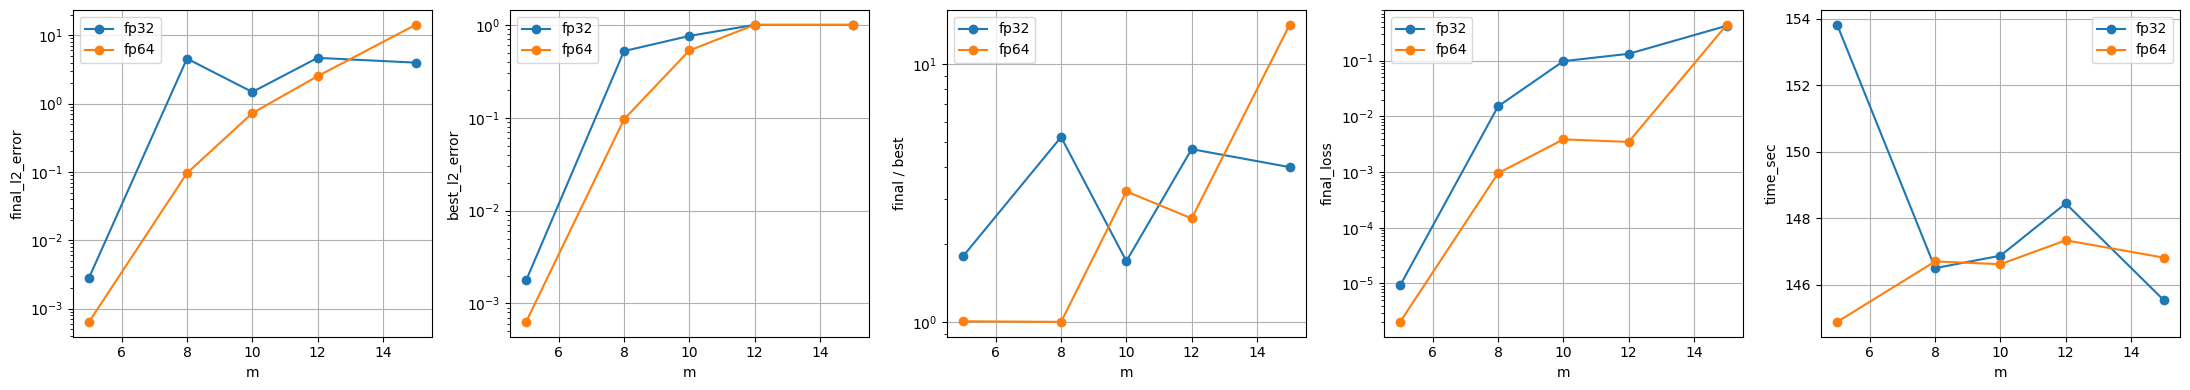

In [7]:
mean_df = (
    df.groupby(["m", "dtype"])[
        ["final_l2_error", "best_l2_error", "l2_ratio", "final_loss", "time_sec"]
    ]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(1, 5, figsize=(22, 4))

for dtype in dtype_values:
    part = mean_df[mean_df["dtype"] == dtype].sort_values("m")
    ax[0].plot(part["m"], part["final_l2_error"], "o-", label=dtype)
    ax[1].plot(part["m"], part["best_l2_error"], "o-", label=dtype)
    ax[2].plot(part["m"], part["l2_ratio"], "o-", label=dtype)
    ax[3].plot(part["m"], part["final_loss"], "o-", label=dtype)
    ax[4].plot(part["m"], part["time_sec"], "o-", label=dtype)

for a in ax:
    a.grid(True)
    a.set_xlabel("m")
    a.legend()

ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")
ax[3].set_yscale("log")
ax[0].set_ylabel("final_l2_error")
ax[1].set_ylabel("best_l2_error")
ax[2].set_ylabel("final / best")
ax[3].set_ylabel("final_loss")
ax[4].set_ylabel("time_sec")

fig.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


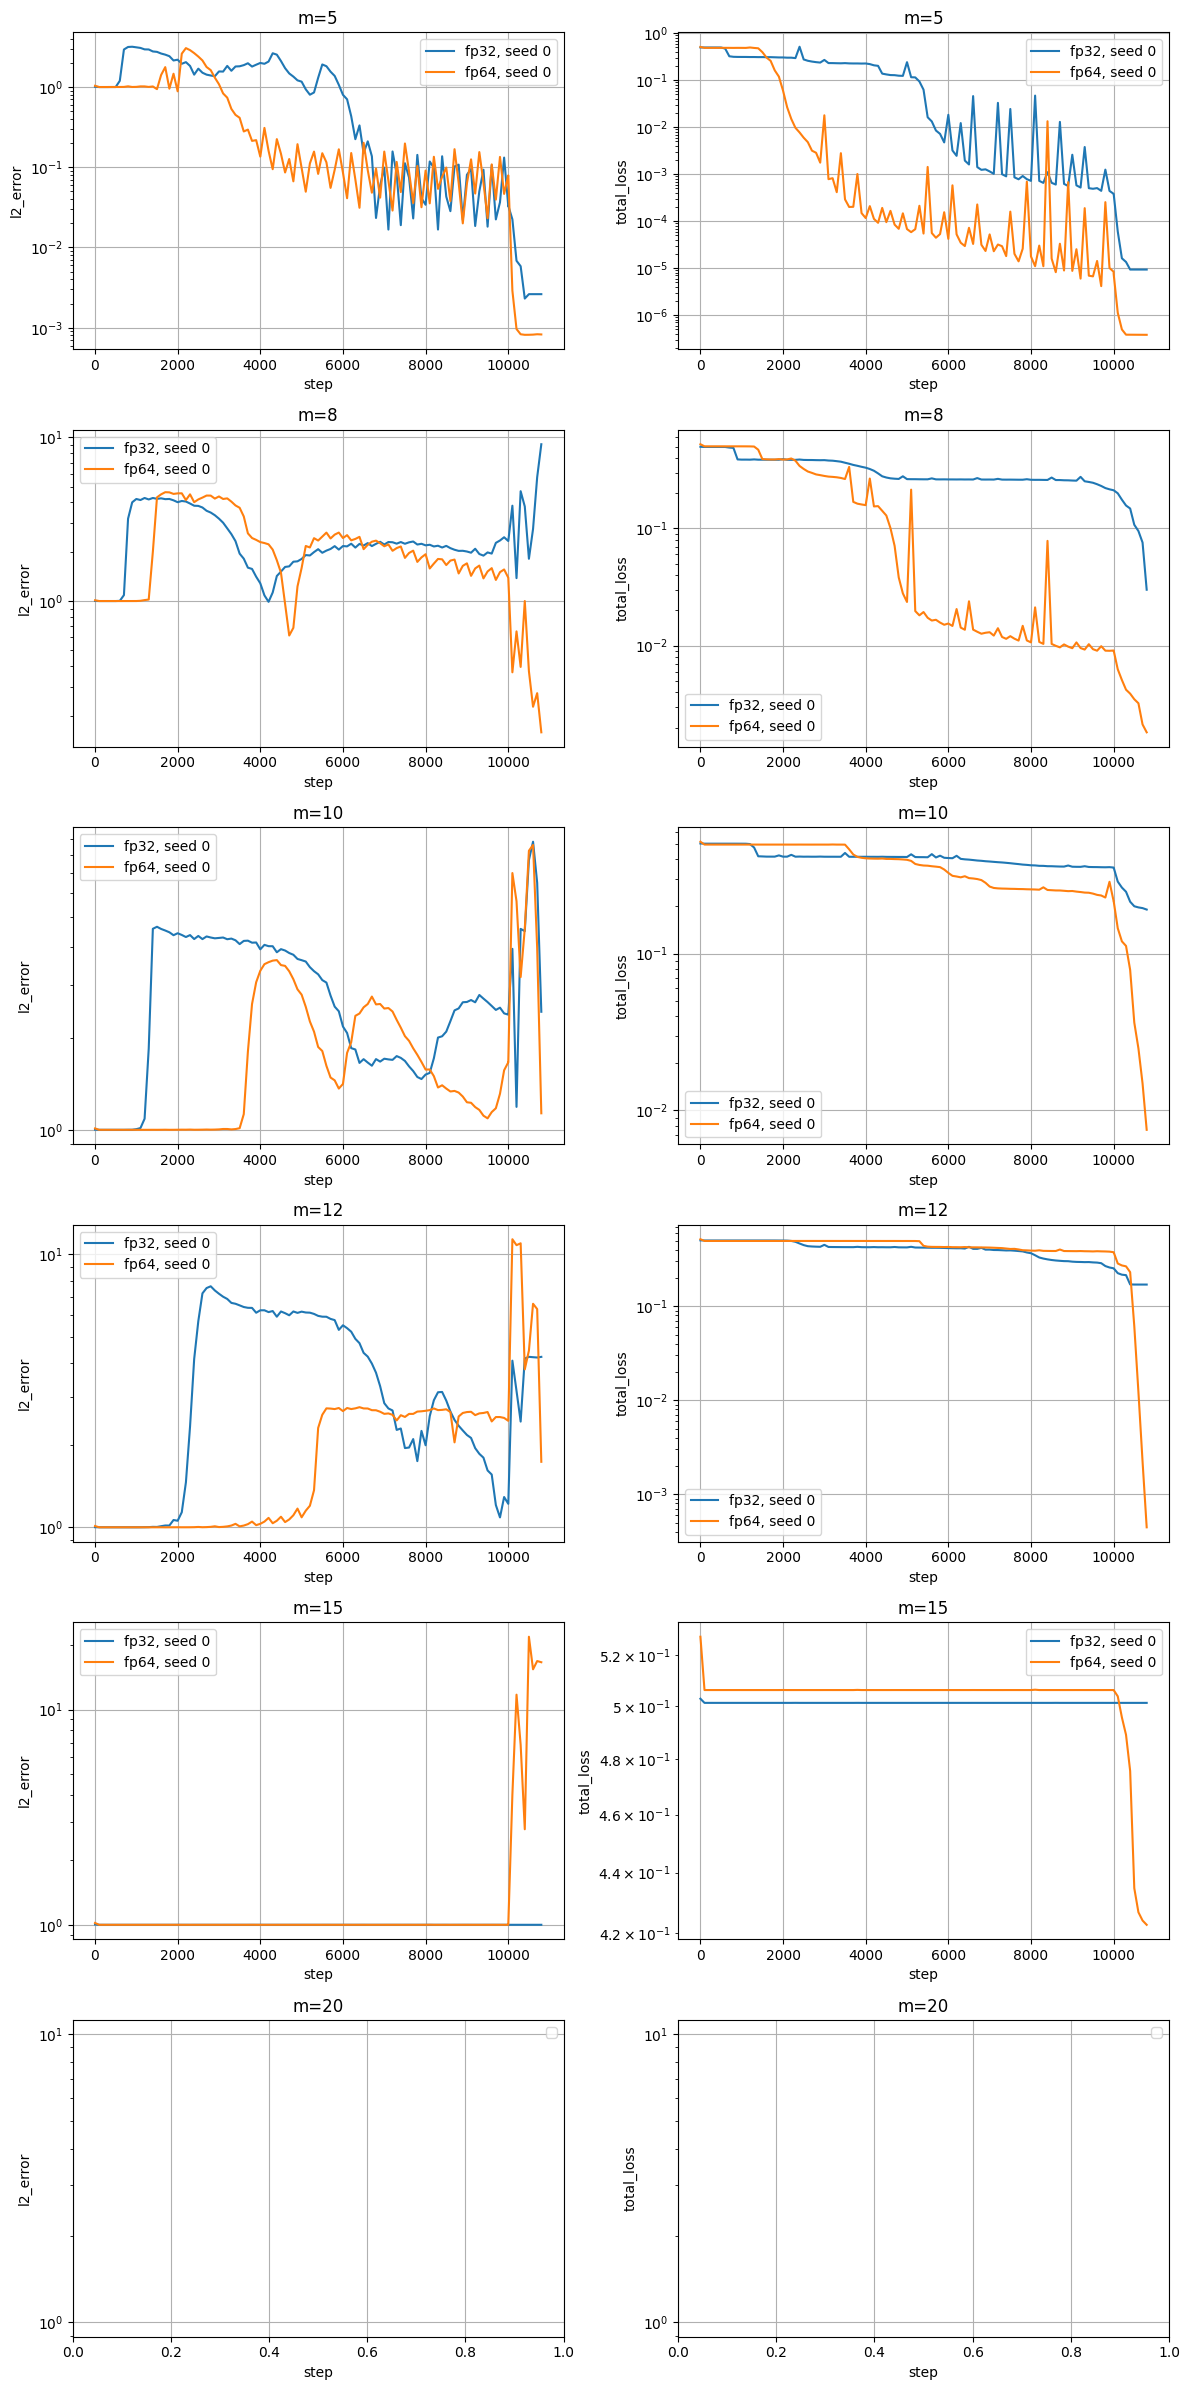

In [8]:
fig, ax = plt.subplots(len(m_values), 2, figsize=(12, 4 * len(m_values)))
ax = np.array(ax).reshape(len(m_values), 2)

for i, m in enumerate(m_values):
    for dtype in dtype_values:
        seed = seed_values[0]
        p = work_dir / "runs" / f"helmholtz_m{m}_{dtype}_{seed}" / "metrics.csv"
        if p.exists():
            h = pd.read_csv(p)
            label = f"{dtype}, seed {seed}"
            ax[i, 0].plot(h["step"], h["l2_error"], label=label)
            ax[i, 1].plot(h["step"], h["total_loss"], label=label)

    ax[i, 0].set_title(f"m={m}")
    ax[i, 1].set_title(f"m={m}")
    ax[i, 0].set_yscale("log")
    ax[i, 1].set_yscale("log")
    ax[i, 0].set_xlabel("step")
    ax[i, 1].set_xlabel("step")
    ax[i, 0].set_ylabel("l2_error")
    ax[i, 1].set_ylabel("total_loss")
    ax[i, 0].grid(True)
    ax[i, 1].grid(True)
    ax[i, 0].legend()
    ax[i, 1].legend()

fig.tight_layout()
plt.show()

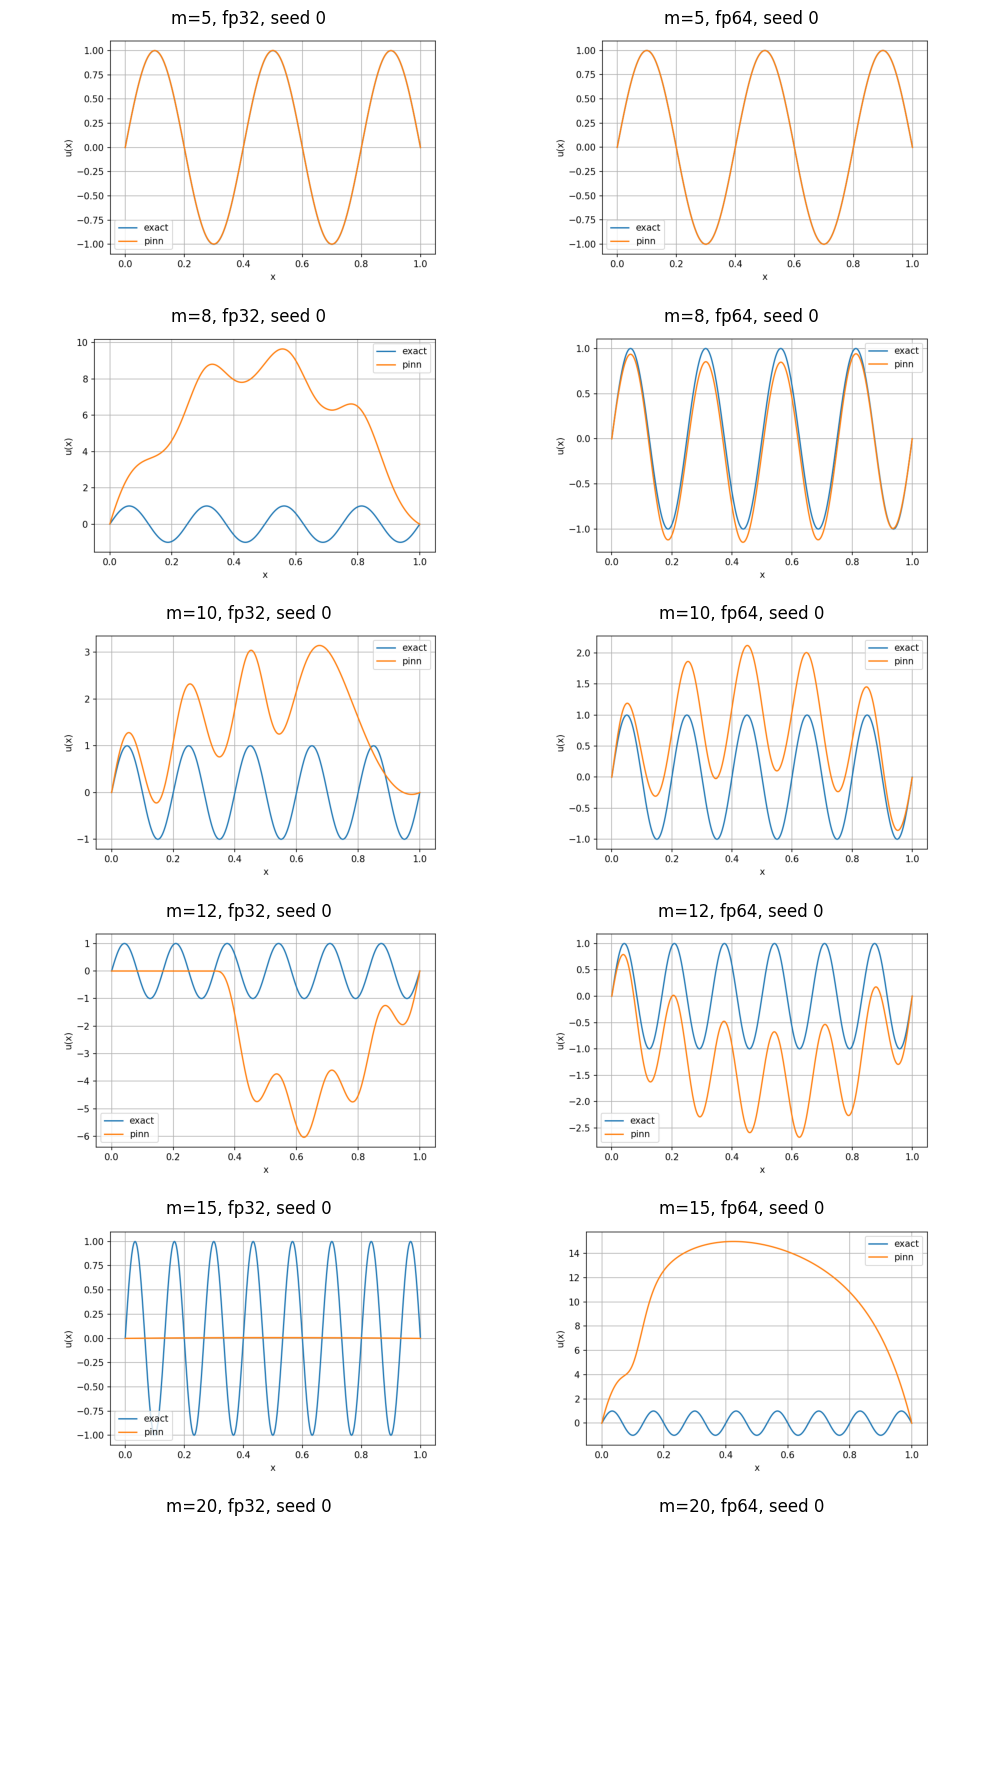

In [9]:
fig, ax = plt.subplots(
    len(m_values), len(dtype_values), figsize=(5 * len(dtype_values), 3 * len(m_values))
)
ax = np.array(ax).reshape(len(m_values), len(dtype_values))

for i, m in enumerate(m_values):
    for j, dtype in enumerate(dtype_values):
        seed = seed_values[0]
        p = work_dir / "runs" / f"helmholtz_m{m}_{dtype}_{seed}" / "solution_t1.png"
        ax[i, j].set_title(f"m={m}, {dtype}, seed {seed}")
        ax[i, j].axis("off")
        if p.exists():
            img = plt.imread(p)
            ax[i, j].imshow(img)

fig.tight_layout()
plt.show()